Total dataset: (2400, 128, 128, 3)
Train: (1680, 128, 128, 3)
Val: (360, 128, 128, 3)
Test: (360, 128, 128, 3)


2026-04-21 06:58:38.193125: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 53s 241ms/step - accuracy: 0.7231 - loss: 0.5578 - val_accuracy: 0.7390 - val_loss: 0.5087
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 50s 237ms/step - accuracy: 0.7340 - loss: 0.5149 - val_accuracy: 0.7692 - val_loss: 0.4749
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 51s 240ms/step - accuracy: 0.7681 - loss: 0.4781 - val_accuracy: 0.7710 - val_loss: 0.4806
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 51s 242ms/step - accuracy: 0.7779 - loss: 0.4651 - val_accuracy: 0.7823 - val_loss: 0.4703
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 50s 237ms/step - accuracy: 0.7702 - loss: 0.4711 - val_accuracy: 0.7921 - val_loss: 0.4434
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step
Mean IoU: 0.3017896706822204
Mean Dice: 0.40695054633103733


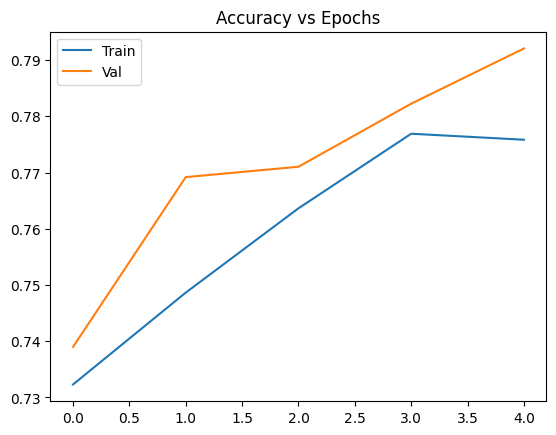

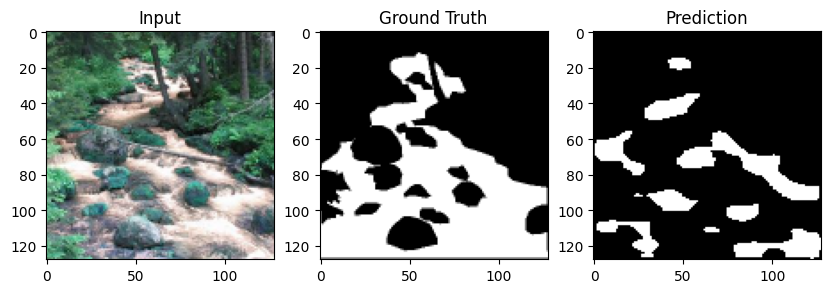

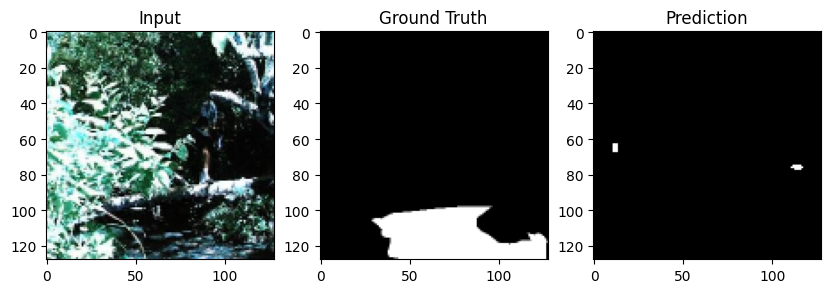

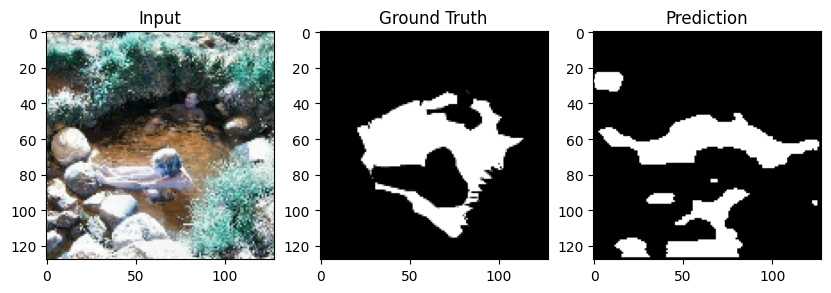

In [9]:
# =========================
# IMPORTS
# =========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# =========================
# PATH
# =========================
IMAGE_SIZE = 128

base_path = "/kaggle/input/datasets/gvclsu/water-segmentation-dataset/water_v2/water_v2"

image_dir = os.path.join(base_path, "JPEGImages")
mask_dir = os.path.join(base_path, "Annotations")

# =========================
# LOAD ALL DATA (RECURSIVE)
# =========================
def load_all_data():
    images = []
    masks = []

    for root, _, files in os.walk(mask_dir):
        for file in files:
            if file.endswith(".png"):
                mask_path = os.path.join(root, file)

                # corresponding image path
                rel_path = os.path.relpath(mask_path, mask_dir)
                img_path_jpg = os.path.join(image_dir, rel_path.replace(".png", ".jpg"))
                img_path_png = os.path.join(image_dir, rel_path)

                if os.path.exists(img_path_jpg):
                    img_path = img_path_jpg
                elif os.path.exists(img_path_png):
                    img_path = img_path_png
                else:
                    continue

                img = cv2.imread(img_path)
                mask = cv2.imread(mask_path, 0)

                if img is None or mask is None:
                    continue

                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE)) / 255.0
                mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE)) / 255.0
                mask = np.expand_dims(mask, axis=-1)

                images.append(img)
                masks.append(mask)

    return np.array(images), np.array(masks)

# =========================
# LOAD DATA
# =========================
X, y = load_all_data()

print("Total dataset:", X.shape)

# =========================
# SPLIT DATA
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================
# MODEL (SIMPLE U-NET)
# =========================
def simple_unet():
    inputs = layers.Input((IMAGE_SIZE, IMAGE_SIZE, 3))

    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)

    u1 = layers.UpSampling2D()(b)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

model = simple_unet()

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# =========================
# TRAIN
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=8
)

# =========================
# METRICS
# =========================
def iou(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.float32)
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + 1e-7)

def dice(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.float32)
    intersection = np.sum(y_true * y_pred)
    return (2 * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

# =========================
# EVALUATE
# =========================
preds = model.predict(X_test)

ious = [iou(y_test[i], preds[i]) for i in range(len(X_test))]
dices = [dice(y_test[i], preds[i]) for i in range(len(X_test))]

print("Mean IoU:", np.mean(ious))
print("Mean Dice:", np.mean(dices))

# =========================
# PLOT
# =========================
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

# =========================
# VISUALIZATION
# =========================
for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(X_test[i])
    plt.title("Input")

    plt.subplot(1,3,2)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow((preds[i].squeeze() > 0.5), cmap='gray')
    plt.title("Prediction")

    plt.show()